# (1) Optimization
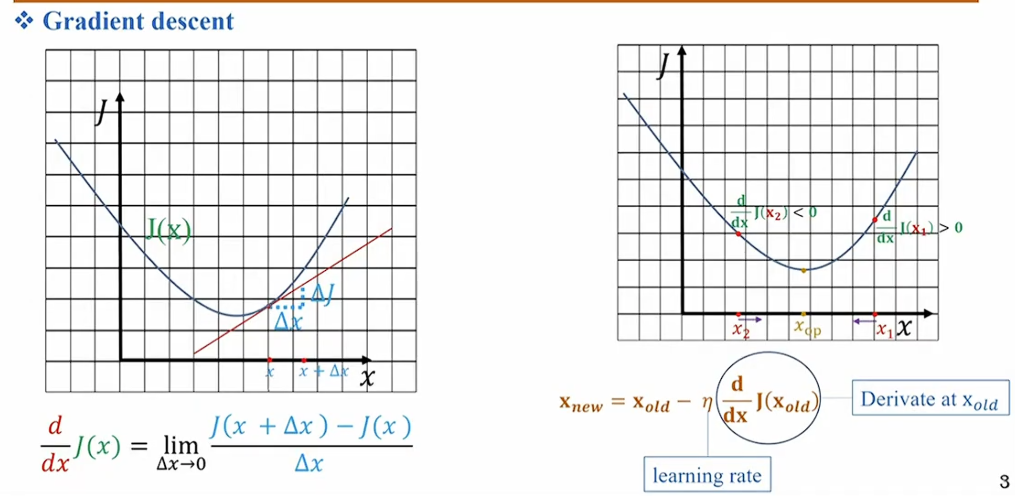
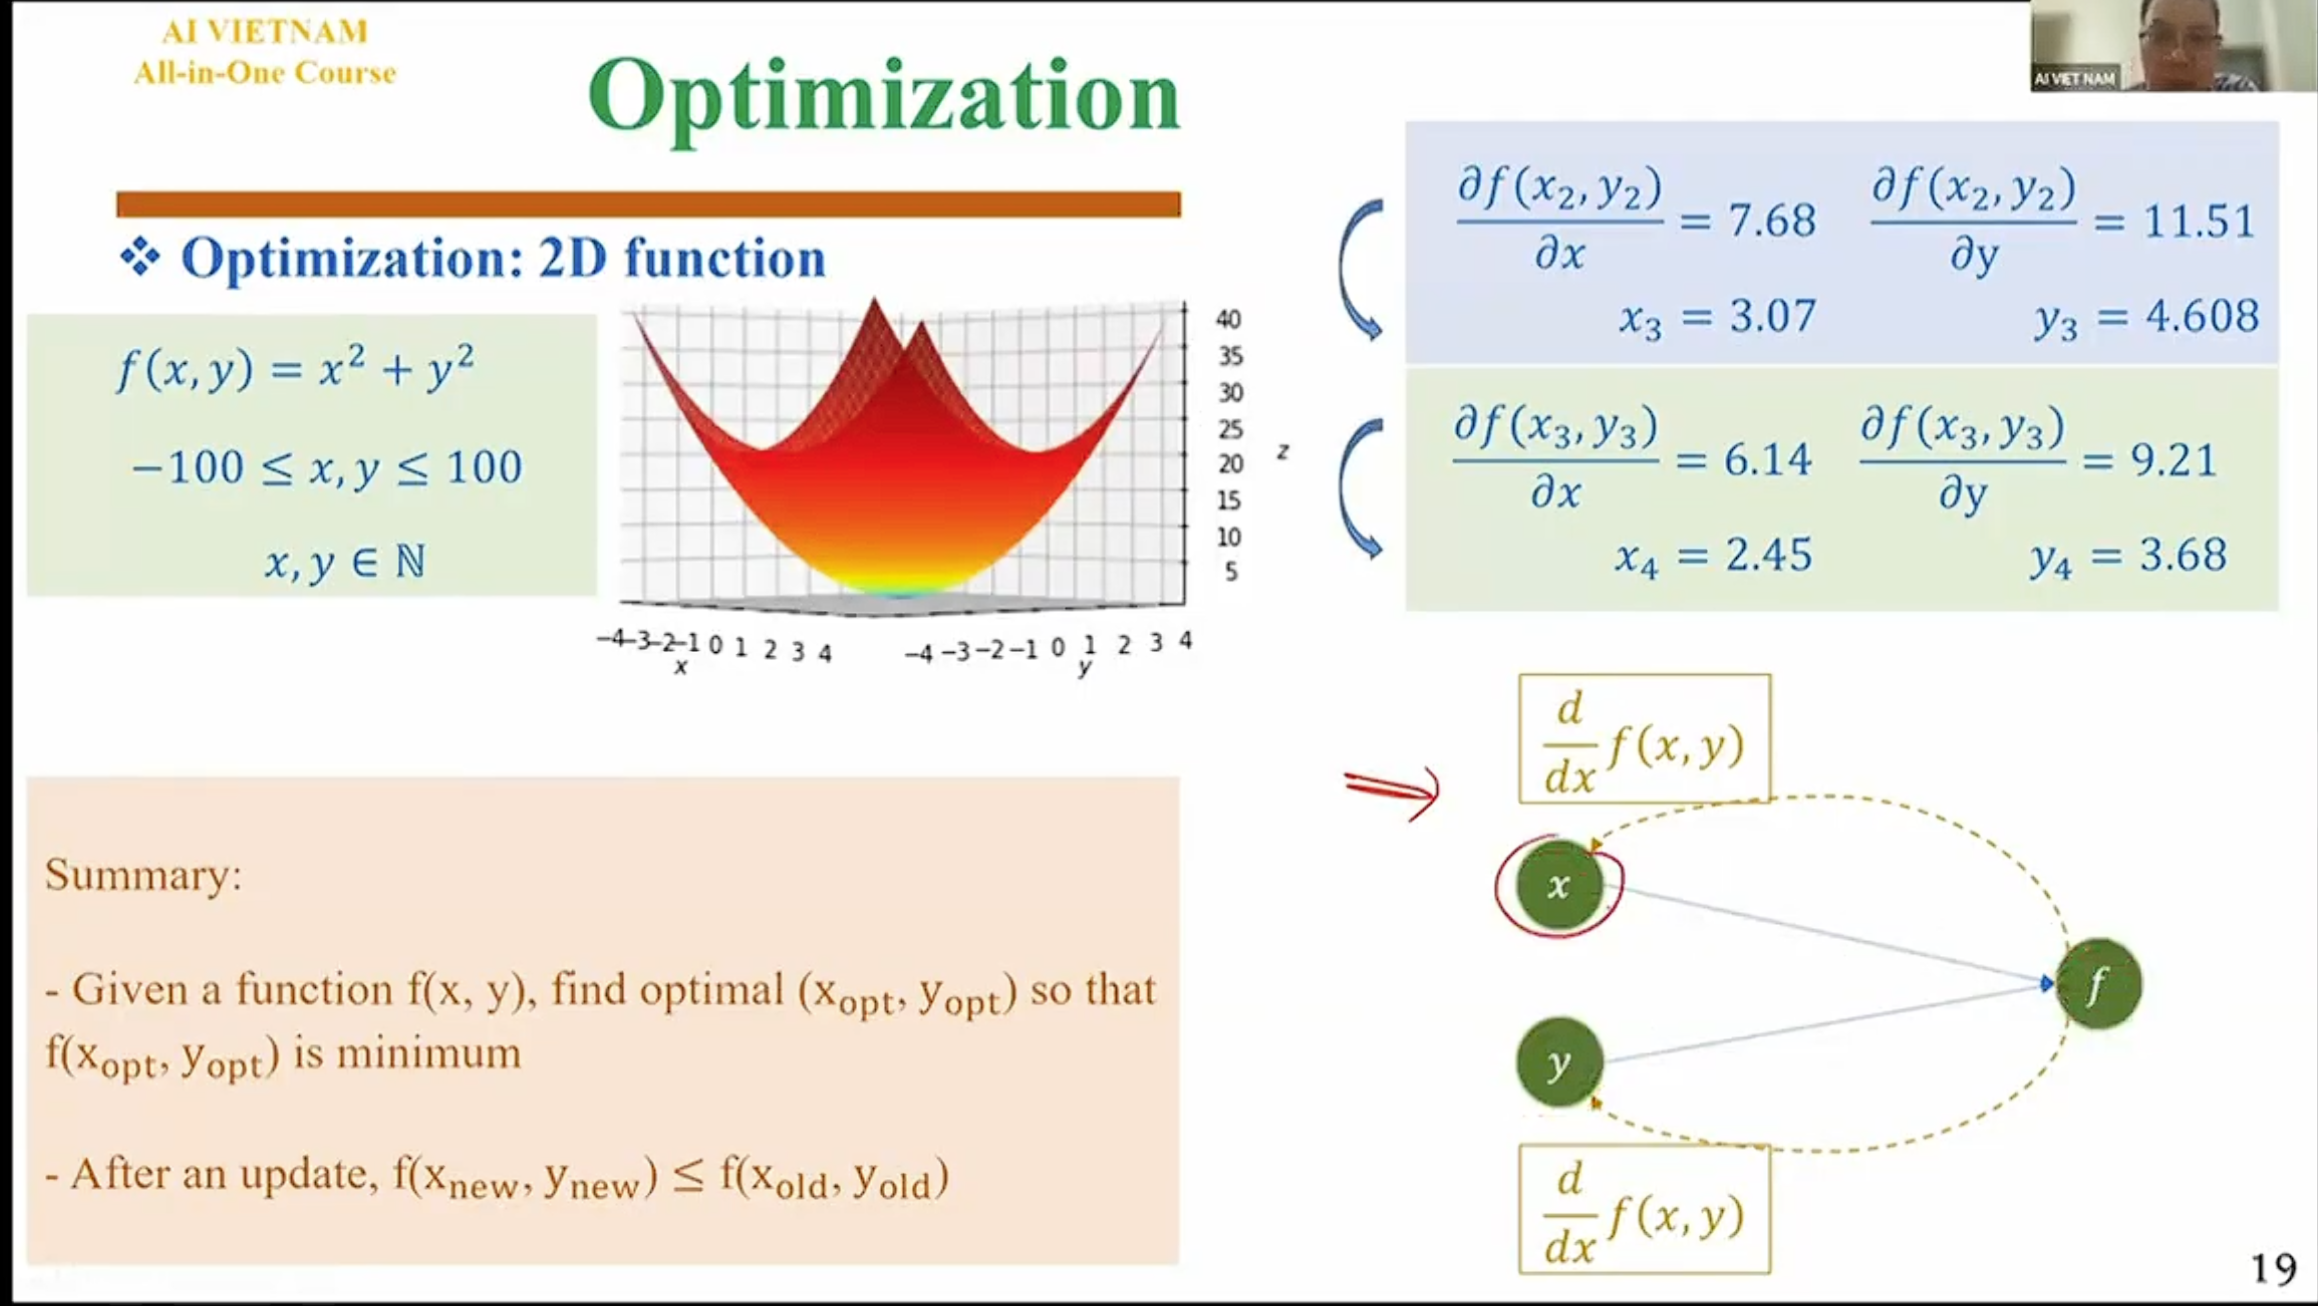

Epoch 0: w = 0.705, b = 0.132
Epoch 10: w = 1.256, b = 0.228
Epoch 20: w = 1.258, b = 0.222
Epoch 30: w = 1.259, b = 0.216
Epoch 40: w = 1.260, b = 0.210
Epoch 50: w = 1.261, b = 0.205
Kết quả cuối cùng: w = 1.261, b = 0.205


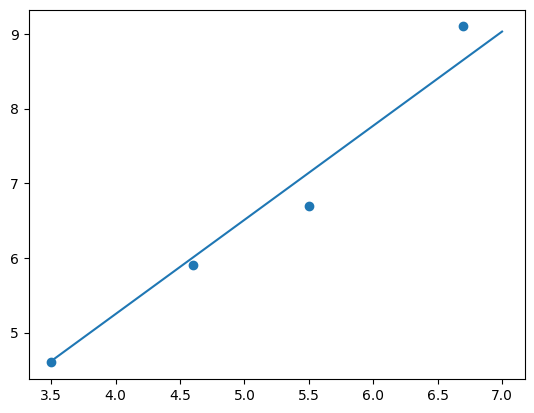

In [25]:
import matplotlib.pyplot as plt
import numpy as np
def predict(x, w, b):
    return w * x + b
def compute_gradient(x, y, w, b):
    n = len(x)
    y_pred = w * x + b
    error = y_pred - y
    dj_dw = (2 / n) * np.sum(error * x)
    dj_db = (2 / n) * np.sum(error)
    return dj_dw, dj_db

w_init = 0
b_init = 0
learning_rate = 0.01
epochs = 51

area = np.array([6.7, 4.6, 3.5, 5.5])
price = np.array([9.1, 5.9, 4.6, 6.7])

w = w_init
b = b_init

for i in range(epochs):
    dj_dw, dj_db = compute_gradient(area, price, w, b)
    w = w - learning_rate * dj_dw
    b = b - learning_rate * dj_db
    if i % 10 == 0:
        print(f"Epoch {i}: w = {w:.3f}, b = {b:.3f}")


print(f"Kết quả cuối cùng: w = {w:.3f}, b = {b:.3f}")

plt.scatter(area, price)
x_data = np.linspace(3.5, 7, 4)
final_result = [predict(x, w, b) for x in x_data]
plt.plot(x_data, final_result)


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Dữ liệu và Hàm tính Gradient (giữ nguyên)
area = np.array([6.7, 4.6, 3.5, 5.5])
price = np.array([9.1, 5.9, 4.6, 6.7])

def compute_gradient(x, y, w, b):
    n = len(x)
    y_pred = w * x + b
    error = y_pred - y
    dj_dw = (2 / n) * np.sum(error * x)
    dj_db = (2 / n) * np.sum(error)
    return dj_dw, dj_db

# 2. Tính toán trước lịch sử cập nhật (để animation mượt hơn)
w = 0.0
b = 0.0
alpha = 0.01
epochs = 50
history = []

for i in range(epochs):
    dj_dw, dj_db = compute_gradient(area, price, w, b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db
    history.append((w, b, i))

# 3. Thiết lập biểu đồ
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(area, price, color='blue', label='Data points')
line, = ax.plot([], [], color='red', label='Regression Line')
text = ax.text(0.05, 0.9, '', transform=ax.transAxes)

ax.set_xlim(min(area)-1, max(area)+1)
ax.set_ylim(min(price)-1, max(price)+1)
ax.set_xlabel('Area')
ax.set_ylabel('Price')
ax.set_title('Gradient Descent Animation')
ax.legend()

# 4. Hàm cập nhật frame
def update(frame):
    cur_w, cur_b, epoch = history[frame]
    
    # Vẽ đường thẳng
    x_vals = np.linspace(min(area)-1, max(area)+1, 100)
    y_vals = cur_w * x_vals + cur_b
    line.set_data(x_vals, y_vals)
    
    # Cập nhật thông số text
    text.set_text(f'Epoch: {epoch}\nw: {cur_w:.2f}\nb: {cur_b:.2f}')
    return line, text

# 5. Tạo Animation
ani = FuncAnimation(fig, update, frames=len(history), blit=True, interval=100)

# 6. HIỂN THỊ TRỰC TIẾP TRONG NOTEBOOK
# Lệnh này sẽ render ra một trình phát video bằng JS ngay bên dưới cell
plt.close() # Đóng plot tĩnh thừa để tránh bị in 2 lần
HTML(ani.to_jshtml())

# Các cách chuẩn hóa dữ liệu
Chuẩn hóa dữ liệu (Data Normalization/Feature Scaling) là bước cực kỳ quan trọng trong Machine Learning. Nó đưa các đặc trưng (features) về cùng một phạm vi giá trị, giúp mô hình học nhanh hơn và chính xác hơn.

Dưới đây là 3 cách chuẩn hóa phổ biến nhất, công thức toán học, và khi nào nên dùng từng loại.

**1. Min-Max Scaling (Normalization)**
- Đây là phương pháp quy đổi dữ liệu về một đoạn cố định, thường là [0, 1].
    - Công thức:
    $$x_{new} = \frac{x - x_{min}}{x_{max} - x_{min}}$$
    - Cách hoạt động:
        - Giá trị nhỏ nhất ($x_{min}$) sẽ biến thành 0.
        - Giá trị lớn nhất ($x_{max}$) sẽ biến thành 1.
        - Các giá trị ở giữa được co giãn theo tỷ lệ.
    - Ưu điểm: Giữ nguyên phân phối gốc của dữ liệu (không làm méo dạng đồ thị), chỉ thu nhỏ tỷ lệ.
    - Nhược điểm: Rất nhạy cảm với Outlier (giá trị ngoại lai). Ví dụ: Nếu đa số nhà < 100m² nhưng có 1 căn nhà 10.000m², thì các nhà nhỏ sẽ bị ép hết về gần số 0.
    - Khi nào dùng: Khi dữ liệu không tuân theo phân phối chuẩn (Gaussian) hoặc khi thuật toán yêu cầu đầu vào bị chặn (ví dụ: Neural Networks, xử lý ảnh pixel 0-255).

**2. Standardization (Z-score Normalization)**
- Đây là phương pháp đưa dữ liệu về phân phối có trung bình (mean) = 0 và độ lệch chuẩn (std deviation) = 1.
    - Công thức:
    $$x_{new} = \frac{x - \mu}{\sigma}$$
    - Cách hoạt động:
        - Giá trị bằng trung bình sẽ biến thành 0.
        - Giá trị lớn hơn trung bình sẽ dương, nhỏ hơn sẽ âm.
    - Ưu điểm: Ít bị ảnh hưởng bởi Outlier hơn so với Min-Max. Giúp Gradient Descent hội tụ nhanh hơn rất nhiều.
    - Khi nào dùng: Là lựa chọn mặc định cho hầu hết các thuật toán (Linear Regression, Logistic Regression, SVM). Đặc biệt tốt khi dữ liệu tuân theo phân phối hình chuông (Gaussian).

**3. Robust Scaling**
- Phương pháp này dùng cho dữ liệu có quá nhiều Outlier (giá trị ngoại lai cực đoan) mà việc xóa bỏ chúng không khả thi.
    - Công thức:
    $$x_{new} = \frac{x - Q_2}{Q_3 - Q_1}$$
    (Dùng Trung vị (Median - $Q_2$) và Khoảng tứ phân vị (IQR = $Q_3 - Q_1$))
    - Cách hoạt động: Nó loại bỏ ảnh hưởng của trung bình và phương sai (vốn dễ bị lệch bởi số cực lớn/nhỏ) mà thay vào đó dùng trung vị.
    - Khi nào dùng: Khi dữ liệu của bạn có nhiều nhiễu hoặc giá trị ngoại lai.

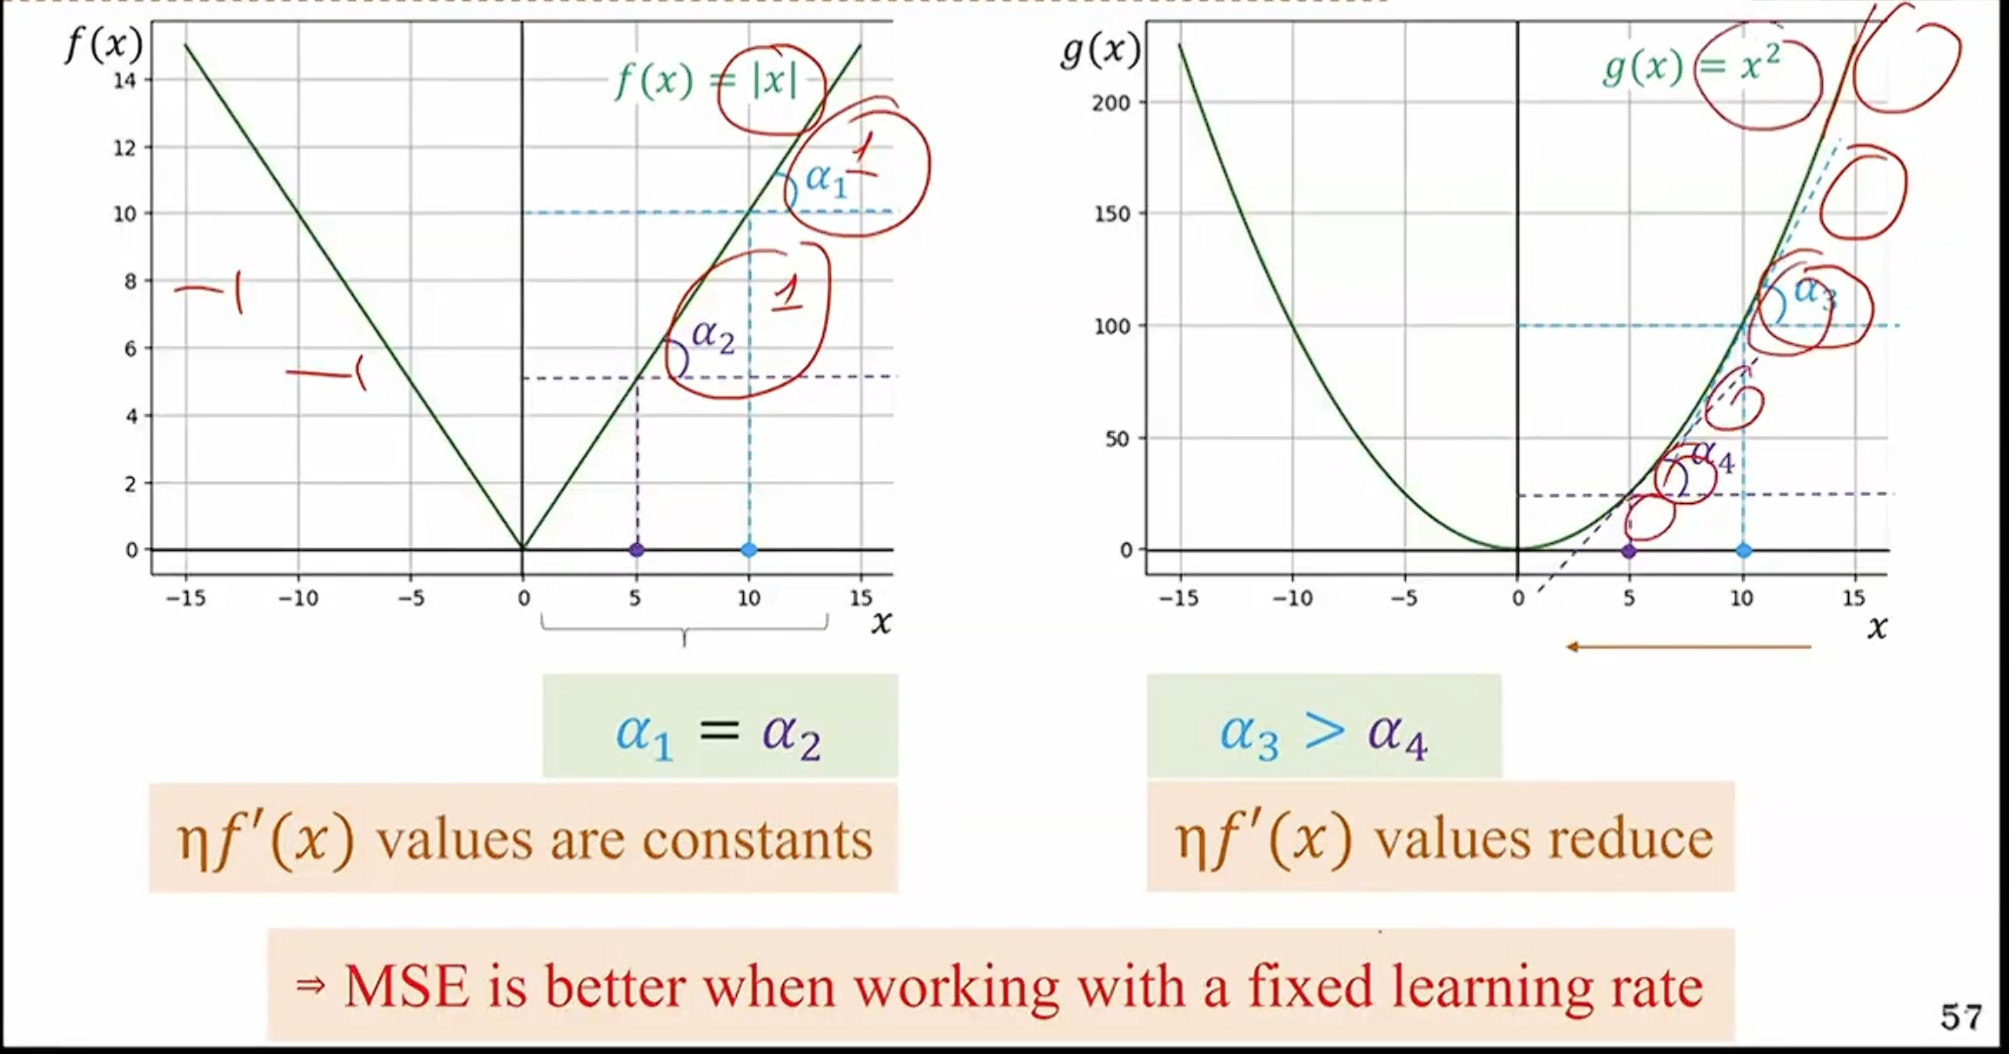

**1. Tại sao MAE khó hội tụ ?**
- MSE ($L = x^2$): Đạo hàm là $2x$.
    - Khi lỗi ($x$) lớn $\rightarrow$ Đạo hàm lớn $\rightarrow$ Bước nhảy lớn.
    - Khi lỗi ($x$) nhỏ (gần đích) $\rightarrow$ Đạo hàm nhỏ $\rightarrow$ Bước nhảy tự động nhỏ lại.
    - Kết quả: Nó giống như bạn lái xe, càng gần vạch đích bạn càng rà phanh nhẹ lại. Xe dừng đúng vạch.
- MAE ($L = |x|$): Đạo hàm là $\pm 1$ (hằng số).
    - Dù lỗi lớn hay lỗi cực nhỏ, đạo hàm vẫn giữ nguyên độ lớn.
    - Kết quả: Với learning rate cố định, khi gần đến đích (đáy cực tiểu), bước nhảy vẫn to như lúc ở xa. Thuật toán sẽ bước qua đáy, rồi bước lại, rồi lại bước qua... tạo thành hiện tượng dao động (oscillation) quanh đích mà không bao giờ dừng hẳn lại được.

**2. Nhưng tại sao người ta vẫn dùng MAE?**
- Nếu MSE "ngoan" như vậy, tại sao MAE vẫn tồn tại? Câu trả lời nằm ở Outlier (Giá trị ngoại lai).
- Hãy tưởng tượng bạn dự đoán giá nhà. Đa số nhà giá 5 tỷ, nhưng có 1 căn biệt thự giá 1000 tỷ do nhập liệu sai (hoặc nó quá đặc biệt).
    - Với MSE (Bình phương lỗi): Chênh lệch của căn 1000 tỷ kia khi bình phương lên sẽ ra một con số khổng lồ. Hàm Loss sẽ bị con số này chi phối hoàn toàn. Để giảm lỗi này, mô hình sẽ cố kéo đường dự đoán về phía căn biệt thự đó $\rightarrow$ Làm sai lệch dự đoán của tất cả các căn nhà bình thường khác.
    - Với MAE (Trị tuyệt đối): Nó chỉ tính khoảng cách thuần túy. Nó coi lỗi 1000 tỷ chỉ là một lỗi lớn, chứ không phóng đại nó lên. Mô hình sẽ "bền vững" (robust) hơn, chấp nhận sai ở căn biệt thự để dự đoán đúng cho đa số các căn còn lại.

**3. Giải pháp: Lấy ưu điểm của cả hai**
- Vì MAE bị vấn đề "bước nhảy không đổi" như bạn phát hiện, người ta có 2 cách khắc phục để vẫn dùng được nó:
- Cách 1: Dynamic Learning Rate (Learning Rate Decay) Thay vì giữ learning rate cố định, ta giảm dần nó theo thời gian.
    - Lúc đầu learning rate to (để đi nhanh).
    - Lúc sau learning rate nhỏ dần (để khi đạo hàm là 1, nhân với learning rate cực nhỏ thì bước nhảy vẫn nhỏ).

- Cách 2: Dùng Huber Loss (Con lai) Đây là hàm loss kết hợp cả hai:
    - Khi lỗi lớn (xa đích): Dùng tính chất của MAE (để không bị outlier kéo lệch).
    - Khi lỗi nhỏ (gần đích): Chuyển sang dùng tính chất của MSE (để đạo hàm nhỏ dần và hội tụ trơn tru).
    $$L_{\delta}(y, \hat{y}) = \begin{cases} \frac{1}{2}(y - \hat{y})^2 & \text{for } |y - \hat{y}| \le \delta \\ \delta |y - \hat{y}| - \frac{1}{2}\delta^2 & \text{otherwise} \end{cases}$$

- Tóm lại
    - MSE: Hội tụ ngon, mượt mà, nhưng sợ nhiễu (outlier).
    - MAE: Chịu nhiễu tốt, nhưng khó hội tụ nếu không giảm learning rate

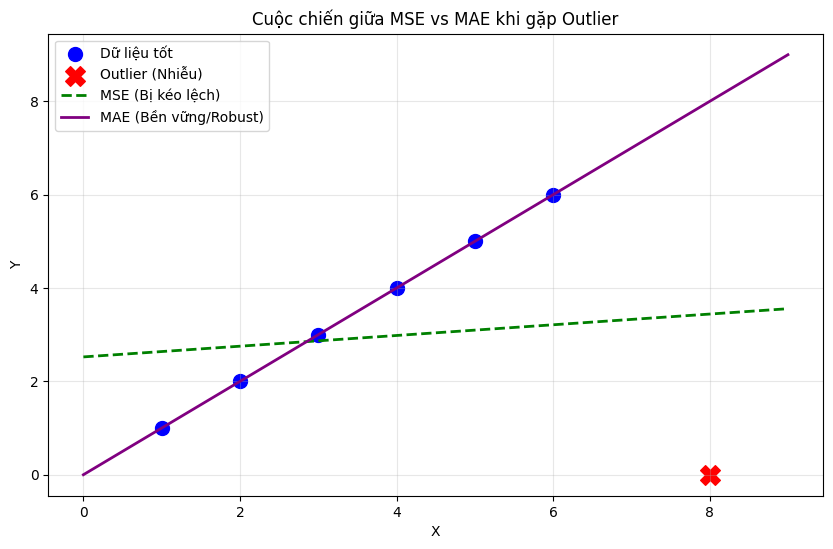

MSE -> w: 0.11, b: 2.52
MAE -> w: 1.00, b: 0.00


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Tạo dữ liệu đẹp (y = x)
x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([1, 2, 3, 4, 5, 6])

# 2. Thêm một Outlier cực đoan (x=8 nhưng y=0 thay vì 8)
x_data = np.append(x, [8])
y_data = np.append(y, [0])

# 3. Định nghĩa 2 hàm Loss
def mse_loss(params):
    w, b = params
    y_pred = w * x_data + b
    return np.mean((y_data - y_pred)**2) # Bình phương lỗi

def mae_loss(params):
    w, b = params
    y_pred = w * x_data + b
    return np.mean(np.abs(y_data - y_pred)) # Trị tuyệt đối lỗi

# 4. Tìm w, b tối ưu cho từng hàm (Optimization)
# Khởi tạo w=1, b=0
init_params = [1.0, 0.0]

# Tối ưu hóa MSE
res_mse = minimize(mse_loss, init_params)
w_mse, b_mse = res_mse.x

# Tối ưu hóa MAE
res_mae = minimize(mae_loss, init_params)
w_mae, b_mae = res_mae.x

# 5. Vẽ biểu đồ so sánh
plt.figure(figsize=(10, 6))

# Vẽ dữ liệu
plt.scatter(x, y, color='blue', s=100, label='Dữ liệu tốt')
plt.scatter([8], [0], color='red', s=200, marker='X', label='Outlier (Nhiễu)')

# Vẽ đường MSE
x_range = np.linspace(0, 9, 100)
y_mse = w_mse * x_range + b_mse
plt.plot(x_range, y_mse, color='green', linestyle='--', linewidth=2, label='MSE (Bị kéo lệch)')

# Vẽ đường MAE
y_mae = w_mae * x_range + b_mae
plt.plot(x_range, y_mae, color='purple', linewidth=2, label='MAE (Bền vững/Robust)')

plt.title('Cuộc chiến giữa MSE vs MAE khi gặp Outlier')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"MSE -> w: {w_mse:.2f}, b: {b_mse:.2f}")
print(f"MAE -> w: {w_mae:.2f}, b: {b_mae:.2f}")

- Đường màu xanh lá (MSE):
    - Nó bị kéo tụt xuống về phía điểm màu đỏ (Outlier).
    - Lý do: Vì sai số ở điểm đỏ là rất lớn, khi bình phương lên nó trở thành "khổng lồ". MSE hoảng sợ trước con số khổng lồ đó và chấp nhận hy sinh độ chính xác của 6 điểm dữ liệu tốt kia chỉ để giảm bớt sai số của điểm đỏ.
    - $\rightarrow$ Đây là lý do MSE nhạy cảm với nhiễu.
- Đường màu tím (MAE):
    - Nó giữ nguyên hướng đi qua các điểm màu xanh, gần như lờ đi điểm đỏ.
    - Lý do: MAE chỉ nhìn thấy sai số ở điểm đỏ là một con số lớn bình thường (không bình phương). Nó nhận ra rằng: "Nếu mình kéo xuống theo thằng đỏ, mình sẽ sai ở 6 thằng xanh kia. Tổng sai số của 6 thằng xanh cộng lại lớn hơn sai số của 1 thằng đỏ". Nên nó chọn đi theo số đông.
    - $\rightarrow$ Đây là tính "Robust" (Bền vững) của MAE.